In [1]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [7]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/reedfrogs.csv", separator=";").with_columns(
    size=pl.col("size").cast(pl.Categorical),
    predators=pl.col("pred").cast(pl.Categorical),
).with_row_index(name="tank")

In [3]:
def create_and_sample_model(data, model_name):
    with pm.Model(coords={
        "tank": data["tank"].to_numpy(),
        "size": data["size"].unique(),
        "predators": data["predators"].unique()
    }) as model:
        # define data
        tank = pm.Data("tank", data["tank"].to_numpy())
        size = pm.Data("size", data["size"].to_physical().to_numpy())
        predators = pm.Data("predators", data["predators"].to_physical().to_numpy())

        # priors
        sigma = pm.Exponential("sigma", 5)
        alpha_bar = pm.Normal("alpha_bar", 0, 1.5)

        alpha_tank = pm.Normal("alpha_tank", alpha_bar, sigma, dims="tank")

        if model_name == "intercept":
            mu = alpha_tank[tank]
        elif model_name == "predation":
            alpha_predators = pm.Normal("b_predation", 0, 1, dims="predators")
            mu = alpha_tank[tank] + alpha_predators[predators]
        elif model_name == "size":
            alpha_size = pm.Normal("alpha_size", 0, 1, dims="size")
            mu = alpha_tank[tank] + alpha_size[size]
        elif model_name == "predation_size":
            alpha_size = pm.Normal("alpha_size", 0, 1, dims="size")
            alpha_predators = pm.Normal("b_predation", 0, 1, dims="predators")
            mu = alpha_tank[tank] + alpha_size[size] + alpha_predators[predators]

        survival_prob = pm.Deterministic("survival_prob", pm.math.invlogit(mu))

        # observed
        survived = pm.Binomial("survived", n=data["density"].to_numpy(),
                               p=survival_prob, observed=data["surv"].to_numpy())

        # sample posterior
        posterior = pm.sample(chains=4, draws=1000)
        posterior_predictive = pm.sample_posterior_predictive(posterior)
        pm.compute_log_likelihood(posterior)

    return model, posterior, posterior_predictive


# Sample all 4 models
models = {model_name: create_and_sample_model(df, model_name) for model_name in ("intercept", "predation", "size", "predation_size")}

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, alpha_bar, alpha_tank]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [alpha_tank, survived]


Output()

Output()

...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, alpha_bar, alpha_tank, alpha_size, b_predation]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 19 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [alpha_size, alpha_tank, b_predation, survived]


Output()

Output()

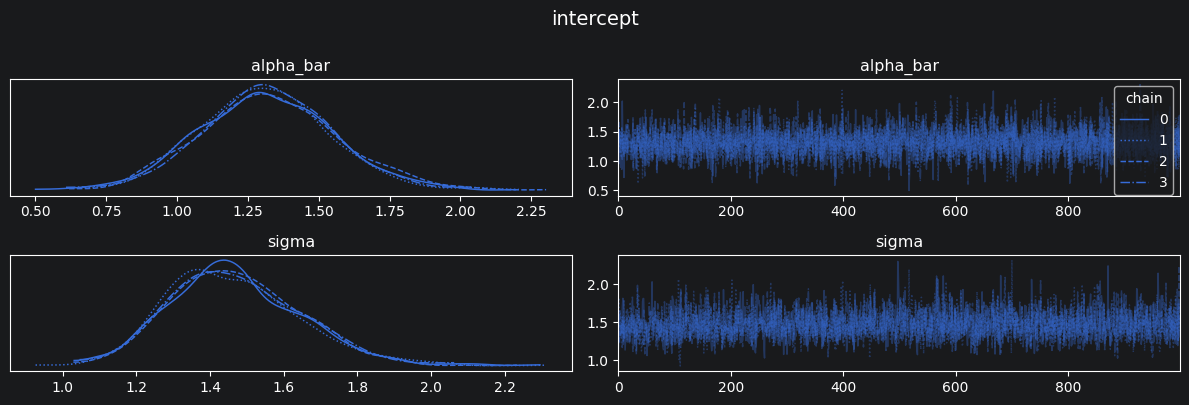

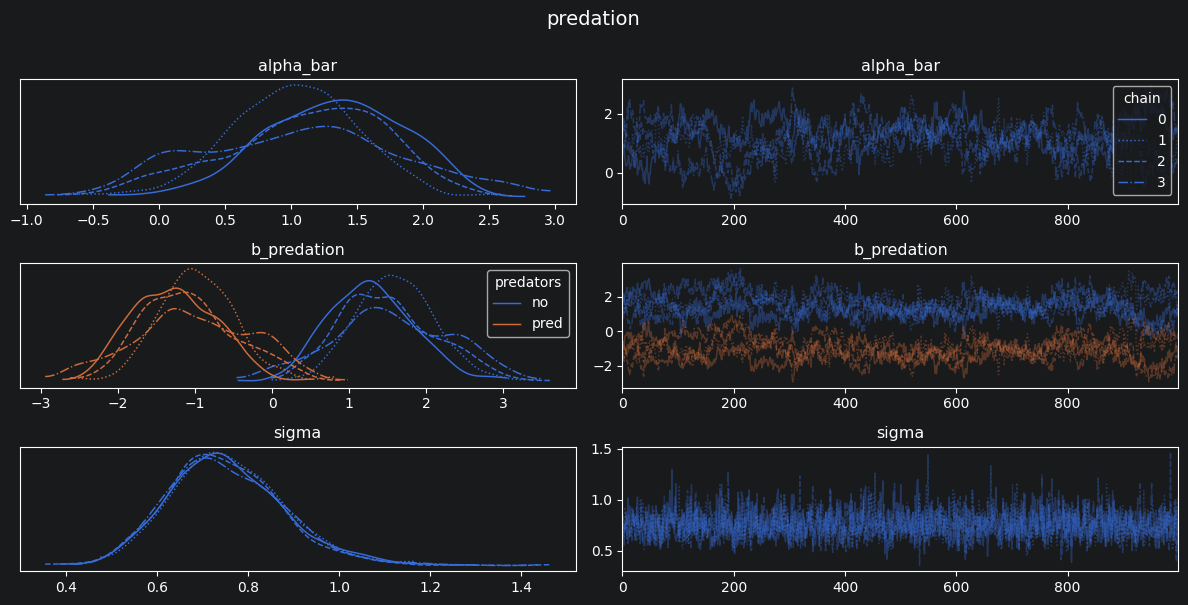

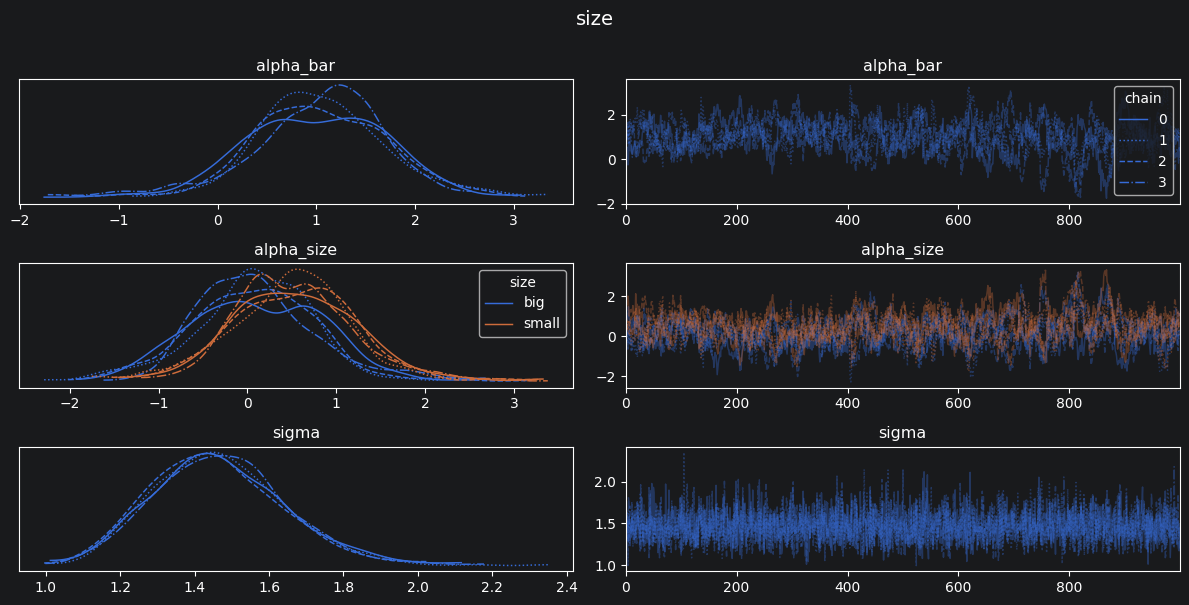

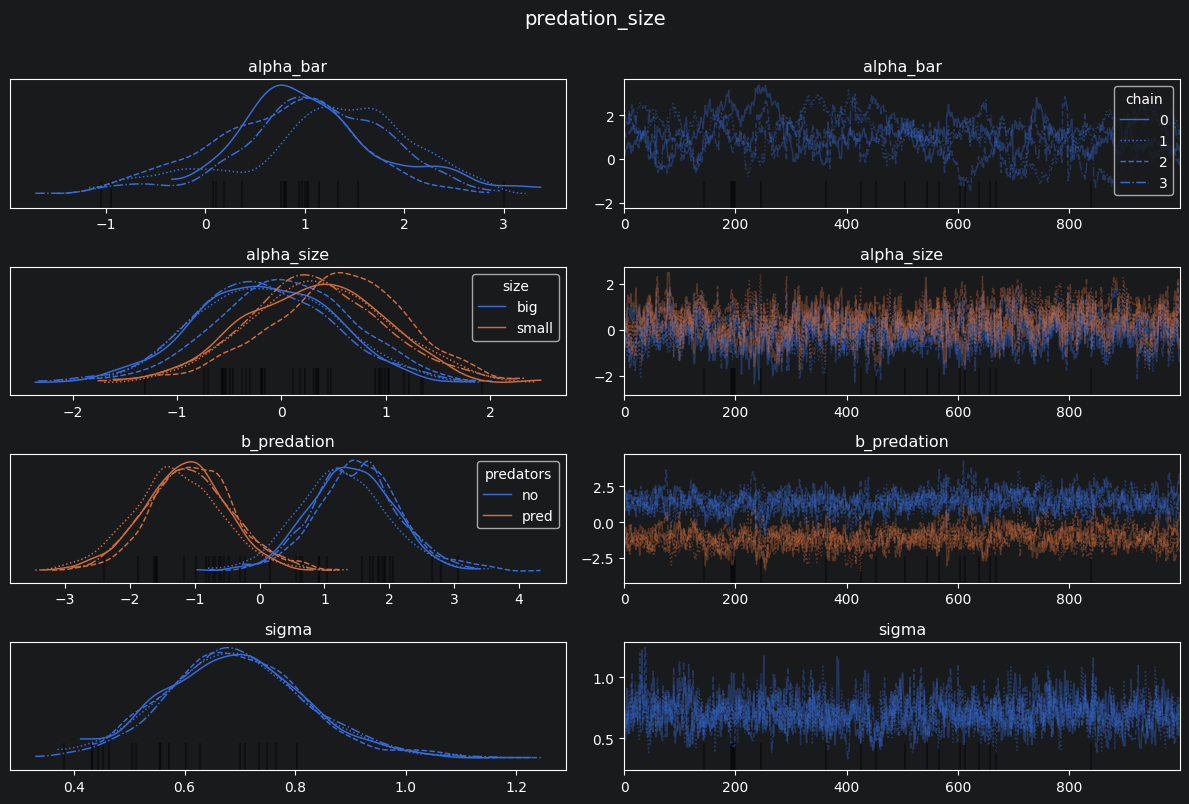

In [4]:
# Plot traces for each model
for model_name, (model, posterior, posterior_predictive) in models.items():
    plot_trace(posterior, title=model_name, var_names=["~alpha_tank", "~survival_prob"], legend=True)

In [5]:
comparison = az.compare({model_name: posterior for model_name, (_, posterior, _) in models.items()}, scale="deviance")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/voutrata/

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
predation,0,214.222856,26.086260,0.000000,7.900504e-01,11.902743,0.000000,True,deviance
predation_size,1,216.555222,26.433714,2.332367,0.000000e+00,11.599866,3.110764,True,deviance
size,2,224.890983,32.767118,10.668128,2.099496e-01,8.224679,9.364291,True,deviance
intercept,3,225.981455,33.445992,11.758599,1.110223e-16,8.528527,9.080511,True,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

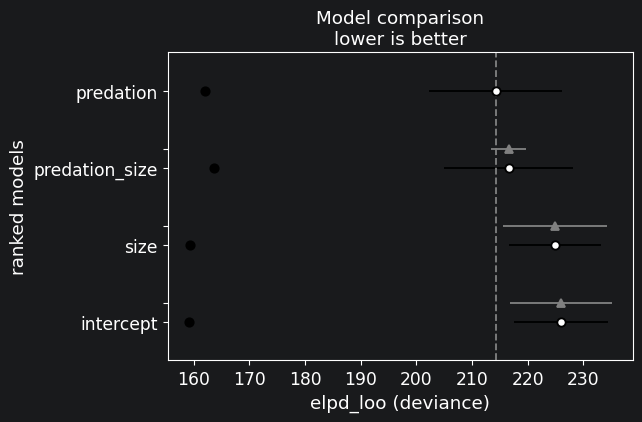

In [6]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)